In [2]:
# Importing and Loading Files

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(train.shape)
print(test.shape)

(891, 12)
(418, 11)


In [3]:
# EDA
train.info()
print(train.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
# Combining the Datasets for preprocessing

test_ids = test['PassengerId']

combined = pd.concat([train.drop('Survived', axis=1), test], axis = 0).reset_index(drop=True)
print(combined.shape)

(1309, 11)


In [5]:
# Feature Engineering

combined['Age'] = combined['Age'].fillna(combined['Age'].median())
combined['Fare'] = combined['Fare'].fillna(combined['Fare'].median())
combined['Embarked'] = combined['Embarked'].fillna(combined['Embarked'].mode()[0])

if 'Cabin' in combined.columns:
    combined.drop('Cabin', axis=1, inplace=True)

combined['FamilySize'] = combined['SibSp'] + combined['Parch'] + 1
combined['IsAlone'] = (combined['FamilySize'] == 1).astype(int)

combined['Title'] = combined['Name'].str.extract(r'([A-Za-z]+)\.')
combined['Title'] = combined['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare'
)

combined['Title'] = combined['Title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})


combined['AgeBand'] = pd.cut(combined['Age'], bins=[0,12,18,35,60,100],
                              labels=[0,1,2,3,4]).astype(int)
combined['FareBand'] = pd.qcut(combined['Fare'], q=4,
                                labels=[0,1,2,3]).astype(int)

combined['Sex'] = combined['Sex'].map({'male':0, 'female':1})
combined['Embarked'] = combined['Embarked'].map({'S':0,'C':1,'Q':2})
combined['Title'] = combined['Title'].map({'Mr':0,'Miss':1,'Mrs':2,'Master':3,'Rare':4})

combined.drop(['Name','Ticket','PassengerId'], axis=1, inplace=True)
print(combined.shape)
combined.head()

(1309, 12)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title,AgeBand,FareBand
0,3,0,22.0,1,0,7.2500,0,2,0,0,2,0
1,1,1,38.0,1,0,71.2833,1,2,0,2,3,3
2,3,1,26.0,0,0,7.9250,0,1,1,1,2,1
3,1,1,35.0,1,0,53.1000,0,2,0,2,2,3
4,3,0,35.0,0,0,8.0500,0,1,1,0,2,1


In [6]:
# Splitting into train and test

X_train = combined.iloc[:len(train)] # 0 to lenght of train
X_test = combined.iloc[len(train):] # lenght of train till end
y_train = train['Survived'] # Survived label

print(X_train.shape, X_test.shape, y_train.shape)

(891, 12) (418, 12) (891,)


In [7]:
# Training with Random Forest Classifier with Cross Validation

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

scores = cross_val_score(rf, X_train, y_train, cv=5, scoring= 'accuracy')

print(f'CV Accuracy: {scores.mean():.4f} +- {scores.std():.4f}')

CV Accuracy: 0.8294 +- 0.0146


In [8]:
# Fitting and Predicting

rf.fit(X_train, y_train)

predictions = rf.predict(X_test)
print(predictions[:10]) # First 10 Predictions

[0 0 0 0 1 0 1 0 1 0]


C:\Users\Anay Duggal\AppData\Local\Temp\ipykernel_19076\2249181057.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y = feat_imp.index, palette='viridis')


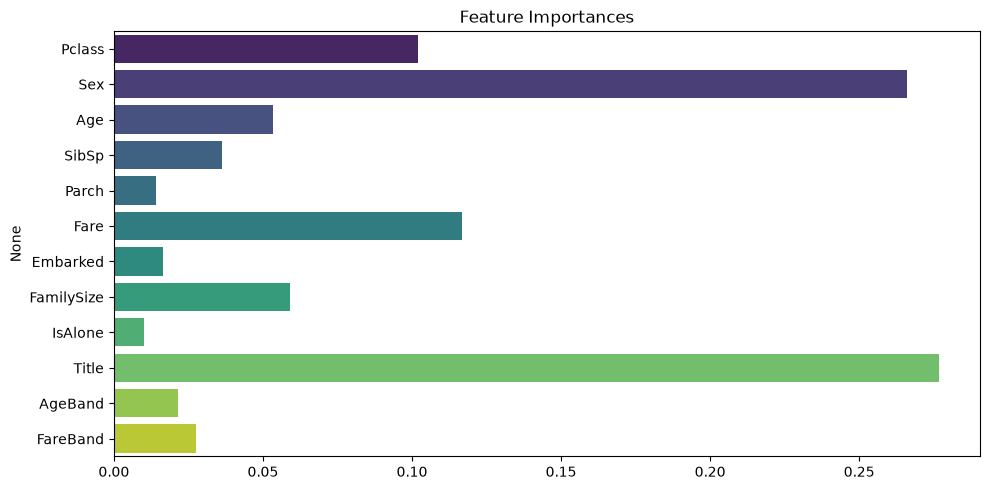

In [9]:
# Feature Importance Plot

feat_imp = pd.Series(rf.feature_importances_, index = X_train.columns)

plt.figure(figsize=(10,5))
sns.barplot(x=feat_imp.values, y = feat_imp.index, palette='viridis')

plt.title('Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [10]:
submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived': predictions
})

submission.to_csv('submission.csv', index=False)
print(submission.head())
print('Submission.csv saved!')

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
Submission.csv saved!


In [ ]:
score = acc